# Sprint 4 - Grafos e Dijkstra no CRM

Esta sprint analisa o funil de vendas do CRMed através da teoria dos grafos. Modelamos os status dos leads como nós e o tempo/esforço de transição como arestas direcionadas com pesos.

## Tarefa 1: Representar o fluxo como grafo
Definimos as etapas do CRM e os custos em horas para cada transição. Existem atalhos (fast-tracks) para leads com maior intenção.

O grafo será criado em um dicionário puro em Python, onde as chaves são as origens, e os valores são dicionários com os destinos e os pesos. Usaremos o `networkx` e o `matplotlib` apenas para fins ilustrativos na visualização do grafo na tela.

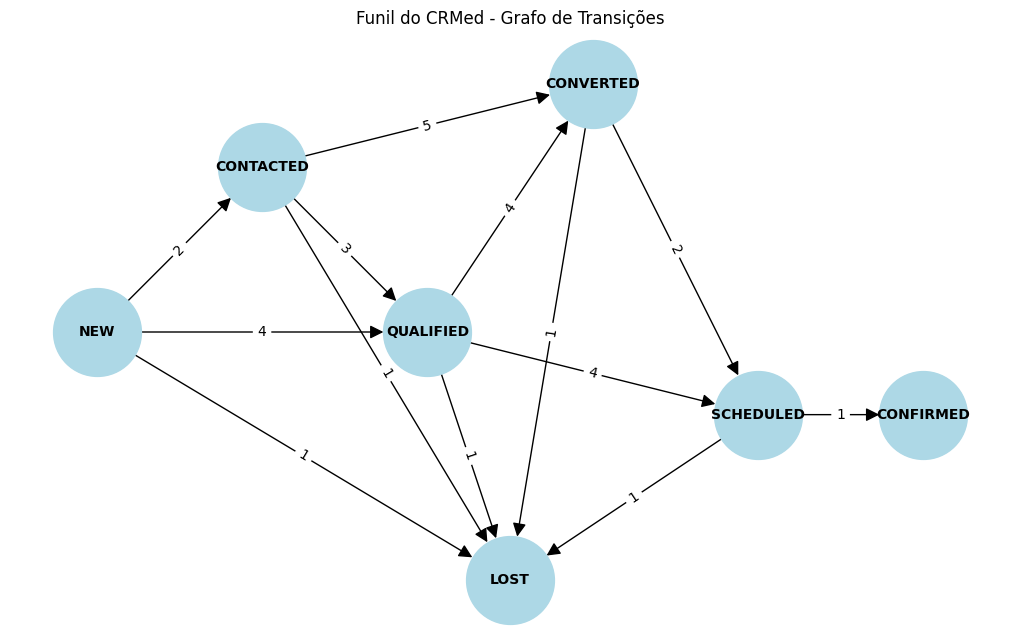

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

crm_graph = {
    'NEW': {'CONTACTED': 2, 'QUALIFIED': 4, 'LOST': 1},
    'CONTACTED': {'QUALIFIED': 3, 'CONVERTED': 5, 'LOST': 1},
    'QUALIFIED': {'CONVERTED': 4, 'SCHEDULED': 4, 'LOST': 1},
    'CONVERTED': {'SCHEDULED': 2, 'LOST': 1},
    'SCHEDULED': {'CONFIRMED': 1, 'LOST': 1},
    'CONFIRMED': {},
    'LOST': {}
}

G = nx.DiGraph()
for origin, destinations in crm_graph.items():
    for dest, weight in destinations.items():
        G.add_edge(origin, dest, weight=weight)

plt.figure(figsize=(10, 6))
pos = {'NEW': (0, 1), 'CONTACTED': (1, 2), 'QUALIFIED': (2, 1), 'CONVERTED': (3, 2.5), 'SCHEDULED': (4, 0.5), 'CONFIRMED': (5, 0.5), 'LOST': (2.5, -0.5)}
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=4000, font_size=10, font_weight='bold', arrows=True, arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title('Funil do CRMed - Grafo de Transições')
plt.savefig('assets/crmed_graph.png', bbox_inches='tight', dpi=300)
plt.show()

## Tarefa 2: Implementar o algoritmo de Dijkstra
Criaremos a função `dijkstra_manual` para encontrar o menor caminho sem depender de funções prontas.

A função inicializa as distâncias de todos os nós como infinito, exceto a origem. Em seguida, ela usa uma fila de prioridade (`heapq`) para sempre explorar o nó mais próximo, atualizando as distâncias dos seus vizinhos e armazenando o caminho mais rápido.

In [2]:
import heapq

def dijkstra_manual(graph, start, end):
    distances = {node: float('infinity') for node in graph}
    distances[start] = 0
    
    previous_nodes = {node: None for node in graph}
    pq = [(0, start)]
    
    while pq:
        current_distance, current_node = heapq.heappop(pq)
        
        if current_distance > distances[current_node]:
            continue
            
        if current_node == end:
            break
            
        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous_nodes[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))
                
    path = []
    current = end
    
    while current is not None:
        path.insert(0, current)
        current = previous_nodes[current]
        
    if distances[end] == float('infinity'):
        return [], float('infinity')
        
    return path, distances[end]

### Executando o algoritmo
Agora vamos executar nossa função manual passando o grafo do CRM, definindo `'NEW'` como início e `'CONFIRMED'` como final.

In [3]:
melhor_caminho, custo_total = dijkstra_manual(crm_graph, 'NEW', 'CONFIRMED')

print("--------------------------------------------------")
print(f"Caminho Otimizado: {' -> '.join(melhor_caminho)}")
print(f"Custo Total (Horas/Esforço): {custo_total}")
print("--------------------------------------------------")

--------------------------------------------------
Caminho Otimizado: NEW -> QUALIFIED -> SCHEDULED -> CONFIRMED
Custo Total (Horas/Esforço): 9
--------------------------------------------------


## Tarefa 3: Interpretar o Resultado

### 1. Qual foi o menor caminho encontrado passo a passo?
O menor caminho (mais rápido/barato) encontrado pelo algoritmo foi: **`NEW -> QUALIFIED -> SCHEDULED -> CONFIRMED`**.

### 2. Qual o custo total desse caminho?
O custo total foi de **9 horas/esforço**, comparado com o fluxo padrão (`NEW -> CONTACTED -> QUALIFIED -> CONVERTED -> SCHEDULED -> CONFIRMED`) que custaria **12 horas**.

### 3. Por que esse fluxo específico é mais eficiente?
Este fluxo ignora as etapas intermediárias de aquecimento manual (`CONTACTED`) e negociação prolongada (`CONVERTED`). No contexto comercial do CRMed, isso reflete o cenário de um **Inbound Lead Quente** — um paciente que já pesquisou o serviço, possivelmente preencheu um formulário de qualificação online (Self-Service) e já chega preparado para agendar a consulta.

A equipe de vendas não precisa "esfriar" o contato tentando convencê-lo ativamente. Direcionar leads altamente qualificados diretamente para o agendamento remove atritos, economiza 3 horas de esforço da operação e acelera o ciclo de vendas.